# K-Nearest Neighbors (KNN) for Forest Covertype Classification

## Importing libraries

In [1]:
import pandas as pd
import warnings
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

## Forest Covertype Dataset

In [2]:
data = pd.read_csv('covtype.csv')

In [3]:
data.shape

(581012, 55)

In [4]:
data.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2596,51,3,258,0,510,221,232,148,6279,...,0,0,0,0,0,0,0,0,0,5
1,2590,56,2,212,-6,390,220,235,151,6225,...,0,0,0,0,0,0,0,0,0,5
2,2804,139,9,268,65,3180,234,238,135,6121,...,0,0,0,0,0,0,0,0,0,2
3,2785,155,18,242,118,3090,238,238,122,6211,...,0,0,0,0,0,0,0,0,0,2
4,2595,45,2,153,-1,391,220,234,150,6172,...,0,0,0,0,0,0,0,0,0,5


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 55 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area1                    581012 non-null  int64
 11  Wilderness_Area2                    581012 non-null 

In [6]:
data.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
count,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,...,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000
mean,2959.365301,155.656807,14.103704,269.428217,46.418855,2350.146611,212.146049,223.318716,142.528263,1980.291226,...,0.090392,0.077716,0.002773,0.003255,0.000205,0.000513,0.026803,0.023762,0.015060,2.051471
std,279.984734,111.913721,7.488242,212.549356,58.295232,1559.254870,26.769889,19.768697,38.274529,1324.195210,...,0.286743,0.267725,0.052584,0.056957,0.014310,0.022641,0.161508,0.152307,0.121791,1.396504
min,1859.000000,0.000000,0.000000,0.000000,-173.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2809.000000,58.000000,9.000000,108.000000,7.000000,1106.000000,198.000000,213.000000,119.000000,1024.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,2996.000000,127.000000,13.000000,218.000000,30.000000,1997.000000,218.000000,226.000000,143.000000,1710.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,3163.000000,260.000000,18.000000,384.000000,69.000000,3328.000000,231.000000,237.000000,168.000000,2550.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
max,3858.000000,360.000000,66.000000,1397.000000,601.000000,7117.000000,254.000000,254.000000,254.000000,7173.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000


## Data Preprocessing

In [7]:
data.isnull().sum() # Checking missing values

Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area1                      0
Wilderness_Area2                      0
Wilderness_Area3                      0
Wilderness_Area4                      0
Soil_Type1                            0
Soil_Type2                            0
Soil_Type3                            0
Soil_Type4                            0
Soil_Type5                            0
Soil_Type6                            0
Soil_Type7                            0
Soil_Type8                            0
Soil_Type9                            0
Soil_Type10                           0
Soil_Type11                           0


### One Hot Encoding of Categorical features
Two categorical features (**By default, these feature have been one hot encoded. So, no need to perform one hot encoding**):
- Wilderness Area: 1 to 4
- Soiltype: 1 to 40

### Standardize numerical features

In [3]:
numerical_columns = ['Elevation', 'Aspect', 'Slope', 'Horizontal_Distance_To_Hydrology', 'Vertical_Distance_To_Hydrology', 'Horizontal_Distance_To_Roadways', 'Hillshade_9am', 'Hillshade_Noon', 'Hillshade_3pm', 'Horizontal_Distance_To_Fire_Points']
scaler = StandardScaler()
data[numerical_columns] = scaler.fit_transform(data[numerical_columns])
data.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,-1.297805,-0.935157,-1.482820,-0.053767,-0.796273,-1.180146,0.330743,0.439143,0.142960,3.246283,...,0,0,0,0,0,0,0,0,0,5
1,-1.319235,-0.890480,-1.616363,-0.270188,-0.899197,-1.257106,0.293388,0.590899,0.221342,3.205504,...,0,0,0,0,0,0,0,0,0,5
2,-0.554907,-0.148836,-0.681563,-0.006719,0.318742,0.532212,0.816364,0.742654,-0.196691,3.126965,...,0,0,0,0,0,0,0,0,0,2
3,-0.622768,-0.005869,0.520322,-0.129044,1.227908,0.474492,0.965786,0.742654,-0.536343,3.194931,...,0,0,0,0,0,0,0,0,0,2
4,-1.301377,-0.988770,-1.616363,-0.547771,-0.813427,-1.256464,0.293388,0.540313,0.195215,3.165479,...,0,0,0,0,0,0,0,0,0,5


In [9]:
data.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
count,5.810120e+05,5.810120e+05,5.810120e+05,5.810120e+05,5.810120e+05,5.810120e+05,5.810120e+05,5.810120e+05,5.810120e+05,5.810120e+05,...,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000
mean,-3.819486e-16,-3.913408e-17,6.417988e-17,-7.122402e-17,8.061620e-17,2.191508e-17,5.060036e-16,3.025064e-16,-1.385346e-16,1.565363e-17,...,0.090392,0.077716,0.002773,0.003255,0.000205,0.000513,0.026803,0.023762,0.015060,2.051471
std,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,1.000001e+00,...,0.286743,0.267725,0.052584,0.056957,0.014310,0.022641,0.161508,0.152307,0.121791,1.396504
min,-3.930094e+00,-1.390866e+00,-1.883448e+00,-1.267604e+00,-3.763928e+00,-1.507225e+00,-7.924808e+00,-1.129659e+01,-3.723844e+00,-1.495469e+00,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,-5.370487e-01,-8.726087e-01,-6.815629e-01,-7.594865e-01,-6.761941e-01,-7.979117e-01,-5.284318e-01,-5.219730e-01,-6.147243e-01,-7.221685e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
50%,1.308455e-01,-2.560618e-01,-1.473917e-01,-2.419591e-01,-2.816503e-01,-2.264844e-01,2.186769e-01,1.356329e-01,1.232511e-02,-2.041175e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
75%,7.273071e-01,9.323547e-01,5.203224e-01,5.390366e-01,3.873587e-01,6.271292e-01,7.042976e-01,6.920686e-01,6.655016e-01,4.302306e-01,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
max,3.209587e+00,1.825901e+00,6.930377e+00,5.304993e+00,9.513327e+00,3.057138e+00,1.563473e+00,1.552015e+00,2.912429e+00,3.921411e+00,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,7.000000


## Feature Selection Techniques
- One Way ANOVA Test
- Chi-square Test
- Mutual Information
- Correlation Test
- PCA

For the results, check out this Kaggle notebook: https://www.kaggle.com/code/rananikhil/feature-selection-techniques

### Correlation Test

In [5]:
CorrBank=data.drop("Cover_Type", axis=1).apply(lambda x: x.corr(data.Cover_Type))

In [11]:
# Convert to DataFrame for better visualization
correlation_df = pd.DataFrame({'Feature': CorrBank.index, 'Correlation': CorrBank.values})

# Sort the correlations by absolute value
correlation_df['AbsoluteCorrelation'] = correlation_df['Correlation'].abs()
correlation_df = correlation_df.sort_values(by='AbsoluteCorrelation', ascending=False)

print(correlation_df)

                               Feature  Correlation  AbsoluteCorrelation
13                    Wilderness_Area4     0.323200             0.323200
0                            Elevation    -0.269554             0.269554
23                         Soil_Type10     0.243876             0.243876
10                    Wilderness_Area1    -0.203913             0.203913
51                         Soil_Type38     0.160170             0.160170
52                         Soil_Type39     0.155668             0.155668
5      Horizontal_Distance_To_Roadways    -0.153450             0.153450
2                                Slope     0.148285             0.148285
35                         Soil_Type22    -0.141746             0.141746
36                         Soil_Type23    -0.135055             0.135055
53                         Soil_Type40     0.128351             0.128351
42                         Soil_Type29    -0.124933             0.124933
15                          Soil_Type2     0.118135

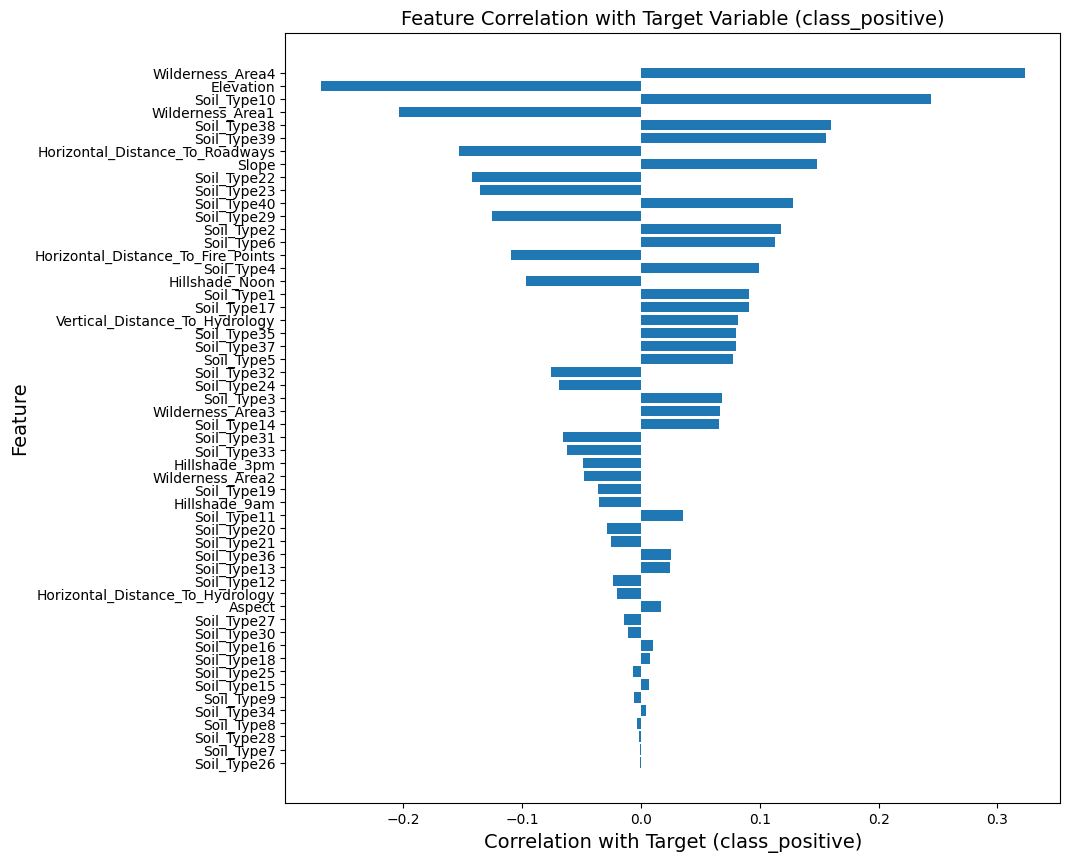

In [12]:
# Visualize the correlations
plt.figure(figsize=(10, 10))
plt.barh(correlation_df['Feature'], correlation_df['Correlation'])
plt.xlabel('Correlation with Target (class_positive)', fontsize = 14)
plt.ylabel('Feature', fontsize = 14)
plt.title('Feature Correlation with Target Variable (class_positive)', fontsize = 14)
plt.gca().invert_yaxis()
plt.savefig('1.png', dpi = 200)
plt.show()

In [13]:
# Set a correlation threshold
threshold = 0.01

# Identify columns with correlation below threshold
low_corr_columns = correlation_df[correlation_df['AbsoluteCorrelation'] < threshold]['Feature']

# Print the columns being dropped
print("Columns dropped due to low correlation with 'y':\n", low_corr_columns)

Columns dropped due to low correlation with 'y':
 29    Soil_Type16
31    Soil_Type18
38    Soil_Type25
28    Soil_Type15
22     Soil_Type9
47    Soil_Type34
21     Soil_Type8
41    Soil_Type28
20     Soil_Type7
39    Soil_Type26
Name: Feature, dtype: object


In [14]:
# Correlation matrix
correlation_matrix = data.corr()

In [15]:
# Filter for pairs with correlation above a threshold
threshold = 0.70
high_correlation_pairs = correlation_matrix[(correlation_matrix.abs() > threshold) & (correlation_matrix.abs() != 1.0)]
high_correlation_pairs = high_correlation_pairs.unstack().dropna().sort_values(ascending=False, key=lambda x: abs(x))

# Display high correlation pairs
print(high_correlation_pairs)

Wilderness_Area1  Wilderness_Area3   -0.793593
Wilderness_Area3  Wilderness_Area1   -0.793593
Hillshade_9am     Hillshade_3pm      -0.780296
Hillshade_3pm     Hillshade_9am      -0.780296
dtype: float64


### PCA

In [16]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10)
X_pca = pca.fit_transform(data.drop('Cover_Type', axis=1))

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
print("Explained variance ratio:", explained_variance_ratio)

Explained variance ratio: [0.22541522 0.19577169 0.15215724 0.10083905 0.06884397 0.05087896
 0.04066091 0.03377177 0.02853887 0.02553204]


- For N_components = 5, 75% variance preserved
- For N_components = 10, 92% variane preserved

## Feature Selection

In [4]:
# Split the dataset
X = data.drop('Cover_Type', axis=1)
y = data['Cover_Type']

In [5]:
# Drop features based on the results from Feature Selection Techniques
rem=['Hillshade_3pm', 'Soil_Type36', 'Soil_Type25', 'Soil_Type28', 'Soil_Type15', 'Soil_Type26', 'Soil_Type16', 'Soil_Type9', 'Soil_Type34', 'Soil_Type37', 'Soil_Type18', 'Soil_Type21', 'Soil_Type7', 'Soil_Type8', 'Soil_Type14']

#Remove the unwanted features
X.drop(rem, axis=1, inplace=True)

## Check if data is imbalanced

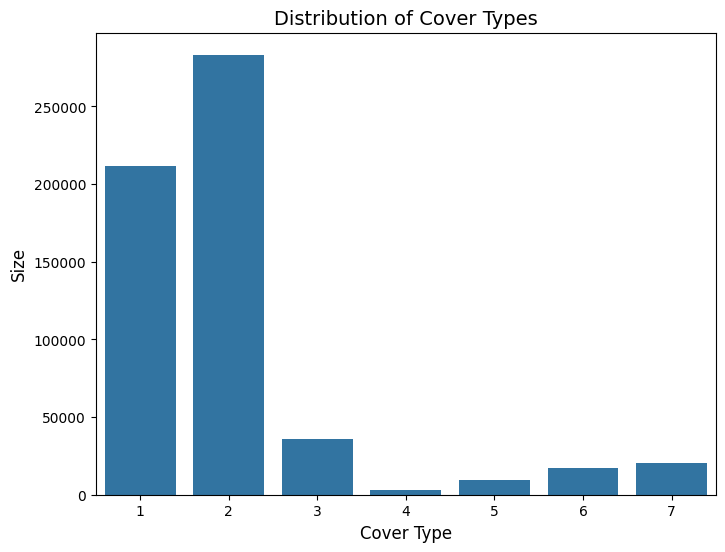

In [19]:
class_dist = data.groupby('Cover_Type').size()
class_label = pd.DataFrame(class_dist, columns=['Size'])

plt.figure(figsize=(8, 6))
bar_plot = sns.barplot(x=class_label.index, y='Size', data=class_label)

# Adding titles and labels with specific font sizes
plt.title('Distribution of Cover Types', fontsize=14)
plt.xlabel('Cover Type', fontsize=12)
plt.ylabel('Size', fontsize=12)

# Adjusting tick label font sizes
bar_plot.tick_params(axis='x', labelsize=10)
bar_plot.tick_params(axis='y', labelsize=10)

plt.savefig('2.png', dpi = 200)
plt.show()

## Training Begins

In [6]:
#Splitting the data into  train and test
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=101)

## K value Selection

## Different Distance Metrics:

### Minkowski (p=1): Manhattan

In [21]:
knn = KNeighborsClassifier(metric='minkowski', p=1)

In [22]:
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

In [23]:
confusion_m = confusion_matrix(y_test, y_pred)
print(confusion_m)

[[59271  3778     3     0    39    15   293]
 [ 3175 81063   239     1   311   174    30]
 [    6   234 10014    79    26   463     0]
 [    0     3   125   655     0    46     0]
 [   76   491    32     0  2261    10     0]
 [   22   282   555    26    15  4349     0]
 [  312    51     0     0     0     0  5779]]


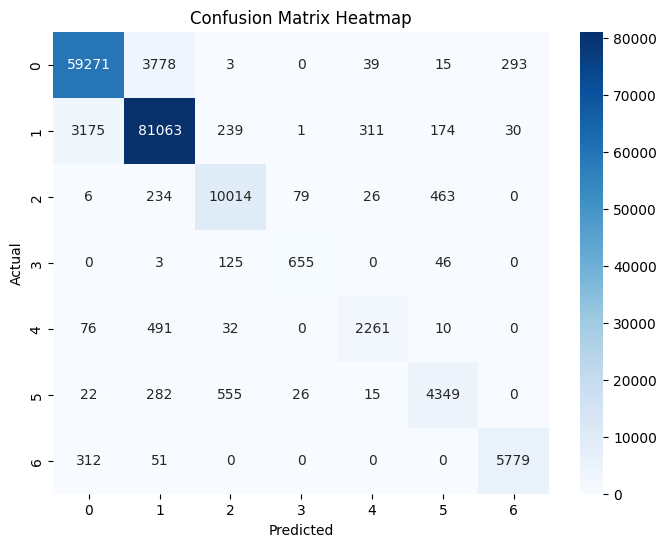

In [24]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_m, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [25]:
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           1       0.94      0.93      0.94     63399
           2       0.94      0.95      0.95     84993
           3       0.91      0.93      0.92     10822
           4       0.86      0.79      0.82       829
           5       0.85      0.79      0.82      2870
           6       0.86      0.83      0.84      5249
           7       0.95      0.94      0.94      6142

    accuracy                           0.94    174304
   macro avg       0.90      0.88      0.89    174304
weighted avg       0.94      0.94      0.94    174304



In [26]:
# # Predict probabilities
# y_score = knn.predict_proba(X_test)

# # Compute ROC curve and ROC area for each class
# fpr = dict()
# tpr = dict()
# roc_auc = dict()
# precision = dict()
# recall = dict()
# average_precision = dict()

# for i in range(n_classes):
#     fpr[i], tpr[i], _ = roc_curve(y_test[:, i], y_score[i][:, 1])
#     roc_auc[i] = auc(fpr[i], tpr[i])
#     precision[i], recall[i], _ = precision_recall_curve(y_test[:, i], y_score[i][:, 1])
#     average_precision[i] = average_precision_score(y_test[:, i], y_score[i][:, 1])

In [ ]:
# Plot ROC curve
plt.figure()
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], label='Class {0} (area = {1:0.2f})'.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Multi-Class')
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Plot Precision-Recall curve
plt.figure()
for i in range(n_classes):
    plt.plot(recall[i], precision[i], label='Class {0} (area = {1:0.2f})'.format(i, average_precision[i]))

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Multi-Class')
plt.legend(loc="lower right")
plt.show()

### Minkowski (p=2): Euclidean

In [17]:
knn = KNeighborsClassifier(metric='minkowski', p=2)

In [18]:
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

In [19]:
confusion_m = confusion_matrix(y_test, y_pred)
print(confusion_m)

[[58710  4292     4     0    45    13   335]
 [ 3661 80480   273     2   335   207    35]
 [    3   269  9878    83    30   559     0]
 [    0     2   144   633     0    50     0]
 [   81   523    35     0  2217    14     0]
 [   17   333   616    31    15  4237     0]
 [  357    50     0     0     2     0  5733]]


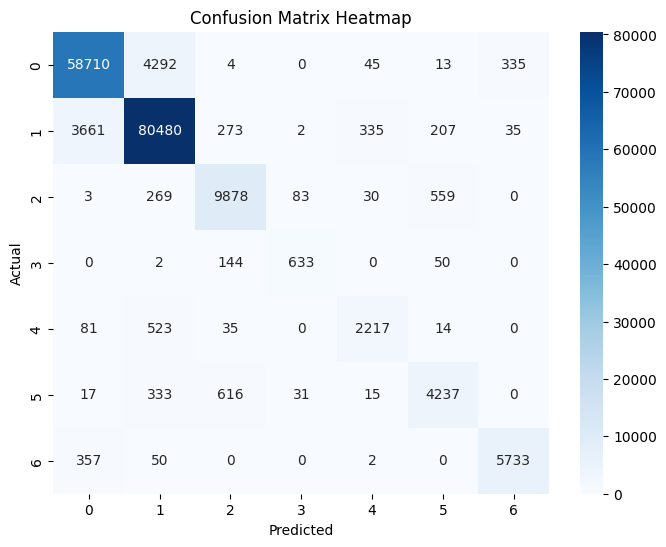

In [20]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_m, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [21]:
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           1       0.93      0.93      0.93     63399
           2       0.94      0.95      0.94     84993
           3       0.90      0.91      0.91     10822
           4       0.85      0.76      0.80       829
           5       0.84      0.77      0.80      2870
           6       0.83      0.81      0.82      5249
           7       0.94      0.93      0.94      6142

    accuracy                           0.93    174304
   macro avg       0.89      0.87      0.88    174304
weighted avg       0.93      0.93      0.93    174304



### Minkowski (p=3)

In [ ]:
knn = KNeighborsClassifier(metric='minkowski', p=3)

SyntaxError: invalid syntax (3146091884.py, line 1)

In [ ]:
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

In [ ]:
confusion_m = confusion_matrix(y_test, y_pred)
print(confusion_m)

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_m, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [ ]:
report = classification_report(y_test, y_pred)
print(report)

### Chebyshev Distance

In [22]:
knn = KNeighborsClassifier(metric='chebyshev')

In [23]:
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

In [24]:
confusion_m = confusion_matrix(y_test, y_pred)
print(confusion_m)

[[57830  5102     4     0    61    16   386]
 [ 4330 79589   320     3   409   299    43]
 [    6   370  9657    89    30   670     0]
 [    0     5   173   602     0    49     0]
 [   97   659    41     0  2059    14     0]
 [   29   405   771    33    19  3992     0]
 [  435    60     0     0     2     0  5645]]


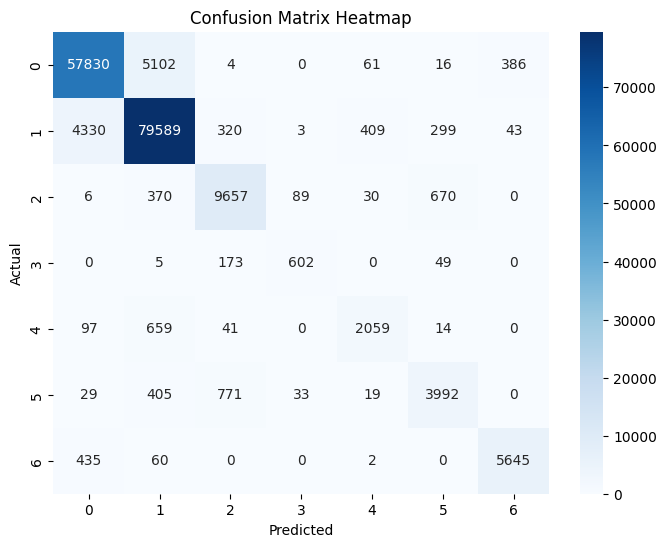

In [25]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_m, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [26]:
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           1       0.92      0.91      0.92     63399
           2       0.92      0.94      0.93     84993
           3       0.88      0.89      0.89     10822
           4       0.83      0.73      0.77       829
           5       0.80      0.72      0.76      2870
           6       0.79      0.76      0.78      5249
           7       0.93      0.92      0.92      6142

    accuracy                           0.91    174304
   macro avg       0.87      0.84      0.85    174304
weighted avg       0.91      0.91      0.91    174304



## Training using X_PCA

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=10)
X_pca = pca.fit_transform(data.drop('Cover_Type', axis=1))

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
print("Explained variance ratio:", explained_variance_ratio)

Explained variance ratio: [0.22541522 0.19577169 0.15215724 0.10083905 0.06884397 0.05087896
 0.04066091 0.03377177 0.02853887 0.02553204]


In [ ]:
#Splitting the data into  train and test
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca,y, test_size=0.3, random_state=101)

In [ ]:
knn_pca = KNeighborsClassifier(metric='minkowski', p=2)

In [ ]:
knn_pca.fit(X_train_pca, y_train_pca)
y_pred_pca = knn_pca.predict(X_test_pca)

In [ ]:
confusion_m_pca = confusion_matrix(y_test_pca, y_pred_pca)
print(confusion_m_pca)

[[57992  5003    11     0    49    21   323]
 [ 4426 79529   388     3   352   258    37]
 [   13   414  9573    96    26   700     0]
 [    0     2   191   595     0    41     0]
 [  113   662    40     0  2040    15     0]
 [   20   432   849    37    15  3896     0]
 [  474    71     0     0     1     0  5596]]


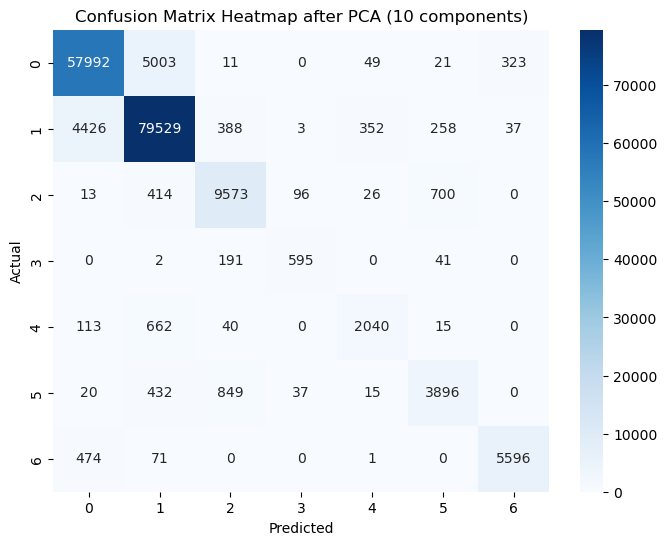

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_m_pca, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap after PCA (10 components)')
plt.savefig('11.png', dpi = 200)
plt.show()

In [ ]:
report = classification_report(y_test_pca, y_pred_pca)
print(report)

              precision    recall  f1-score   support

           1       0.92      0.91      0.92     63399
           2       0.92      0.94      0.93     84993
           3       0.87      0.88      0.88     10822
           4       0.81      0.72      0.76       829
           5       0.82      0.71      0.76      2870
           6       0.79      0.74      0.77      5249
           7       0.94      0.91      0.93      6142

    accuracy                           0.91    174304
   macro avg       0.87      0.83      0.85    174304
weighted avg       0.91      0.91      0.91    174304



In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=5)
X_pca = pca.fit_transform(data.drop('Cover_Type', axis=1))

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
print("Explained variance ratio:", explained_variance_ratio)

Explained variance ratio: [0.22541522 0.19577169 0.15215724 0.10083905 0.06884397]


In [ ]:
#Splitting the data into  train and test
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca,y, test_size=0.3, random_state=101)

In [ ]:
knn_pca = KNeighborsClassifier(metric='minkowski', p=2)

In [ ]:
knn_pca.fit(X_train_pca, y_train_pca)
y_pred_pca = knn_pca.predict(X_test_pca)

In [ ]:
confusion_m_pca = confusion_matrix(y_test_pca, y_pred_pca)
print(confusion_m_pca)

[[51897 10767    22     0    65    37   611]
 [10656 72370   863     8   432   470   194]
 [   83  1447  8306   120    47   819     0]
 [    0    10   231   508     0    80     0]
 [  241  1290    56     0  1275     8     0]
 [   71   982  1197    56    20  2923     0]
 [ 1290   397     0     0     1     0  4454]]


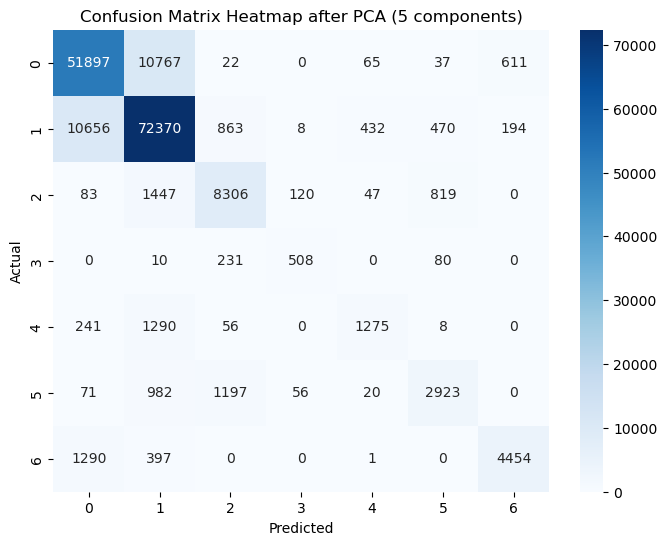

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_m_pca, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap after PCA (5 components)')
plt.savefig('12.png', dpi = 200)
plt.show()

In [ ]:
report = classification_report(y_test_pca, y_pred_pca)
print(report)

              precision    recall  f1-score   support

           1       0.81      0.82      0.81     63399
           2       0.83      0.85      0.84     84993
           3       0.78      0.77      0.77     10822
           4       0.73      0.61      0.67       829
           5       0.69      0.44      0.54      2870
           6       0.67      0.56      0.61      5249
           7       0.85      0.73      0.78      6142

    accuracy                           0.81    174304
   macro avg       0.77      0.68      0.72    174304
weighted avg       0.81      0.81      0.81    174304



## Weighted Euclidean

In [9]:
knn_wt = KNeighborsClassifier(metric='minkowski', p=2, weights='distance')

In [13]:
knn_wt.fit(X_train, y_train)
y_pred = knn_wt.predict(X_test)

In [14]:
confusion_m_wt = confusion_matrix(y_test, y_pred)
print(confusion_m_wt)

[[58990  4024     5     0    54    16   310]
 [ 3386 80731   262     3   353   224    34]
 [    2   214  9931    87    32   556     0]
 [    0     2   119   655     0    53     0]
 [   62   485    31     0  2276    16     0]
 [   13   268   550    23    12  4383     0]
 [  327    49     0     0     2     0  5764]]


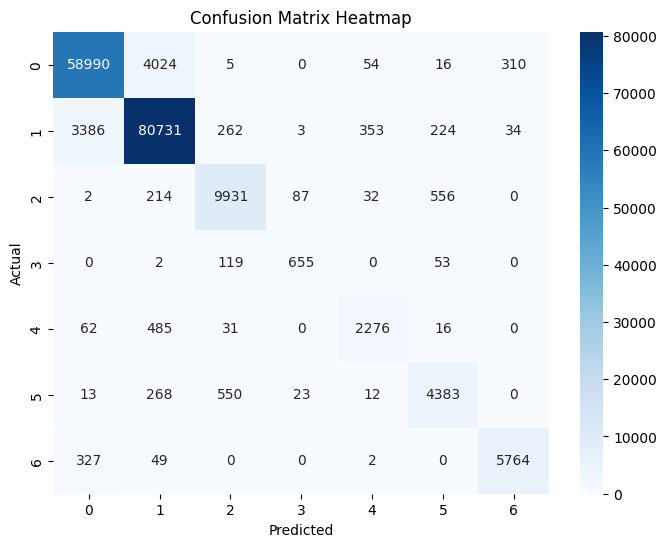

In [15]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_m_wt, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [16]:
report_wt = classification_report(y_test, y_pred)
print(report_wt)

              precision    recall  f1-score   support

           1       0.94      0.93      0.94     63399
           2       0.94      0.95      0.95     84993
           3       0.91      0.92      0.91     10822
           4       0.85      0.79      0.82       829
           5       0.83      0.79      0.81      2870
           6       0.84      0.84      0.84      5249
           7       0.94      0.94      0.94      6142

    accuracy                           0.93    174304
   macro avg       0.89      0.88      0.89    174304
weighted avg       0.93      0.93      0.93    174304



### Weighted Manhattan

In [7]:
knn_wt_p1 = KNeighborsClassifier(metric='minkowski', p=1, weights='distance')

In [8]:
knn_wt_p1.fit(X_train, y_train)
y_pred_wt_p1 = knn_wt_p1.predict(X_test)

In [9]:
confusion_m_wt_p1 = confusion_matrix(y_test, y_pred_wt_p1)
print(confusion_m_wt_p1)

[[59455  3605     5     0    43    15   276]
 [ 2944 81255   241     3   319   195    36]
 [    3   194 10037    86    26   476     0]
 [    0     2   101   672     0    54     0]
 [   57   449    28     0  2325    11     0]
 [   14   226   480    19    11  4499     0]
 [  283    53     0     0     1     0  5805]]


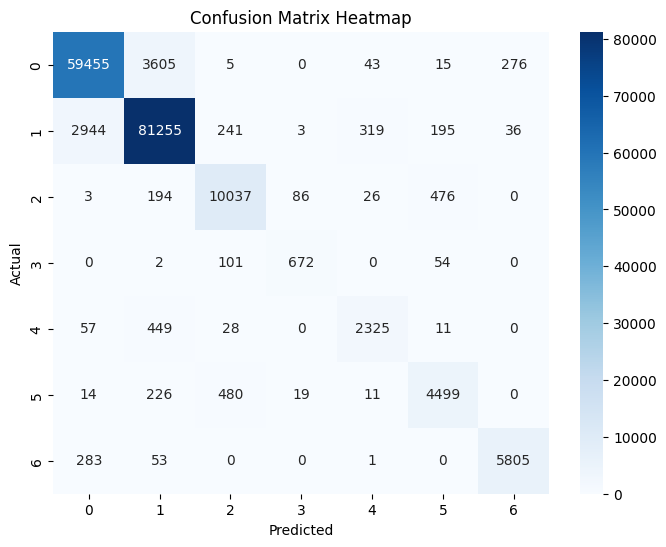

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_m_wt_p1, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Heatmap')
plt.show()

In [11]:
report_wt_p1 = classification_report(y_test, y_pred_wt_p1)
print(report_wt_p1)

              precision    recall  f1-score   support

           1       0.95      0.94      0.94     63399
           2       0.95      0.96      0.95     84993
           3       0.92      0.93      0.92     10822
           4       0.86      0.81      0.84       829
           5       0.85      0.81      0.83      2870
           6       0.86      0.86      0.86      5249
           7       0.95      0.95      0.95      6142

    accuracy                           0.94    174304
   macro avg       0.91      0.89      0.90    174304
weighted avg       0.94      0.94      0.94    174304

